# CS4168 Data Mining - Group Project
## Regression (Predicting Exact Popularity Score)

In addition to classification, you must perform regression modelling using the original
column popularity as the target variable.

## Requirements:
* Use a separate copy of the dataset in which the original popularity column is retained (do not binarise).
* Train a regression model that performs as well as possible.
* Explore more than one modelling approach and justify your final choice.
* Discuss whether predicting exact popularity is more difficult than predicting high/low popularity.

## A. Importing Modules and Dataset

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor


lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [63]:
df = pd.read_csv("./tracks2026.csv")#reads csv set
df.head(5)
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


In [64]:
df.tail(5)

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop
1999,46qnV2b4tq0QqJwIoZwMyJ,25.0,244026,False,0.746,0.570,7,-10.599,1,0.0389,0.6660,0.000005,0.3200,0.657,109.929,4,synth-pop


## B. Pre-Processing

In [65]:
df_reg = df.copy()

df_reg = df_reg.drop(["track_id","track_genre","explicit","mode","key","time_signature"], axis=1)
df_reg = df_reg.dropna()

df_reg = df_reg[df_reg["loudness"] <= 0] # drops tracks with loudness above 0, as those are likely errors

X = df_reg.drop(columns=['popularity'])
y = df_reg['popularity']

X = X.select_dtypes(include='number') # for safety, ensure only numeric values

X.dtypes # for safety, check types

,0
duration_ms,int64
danceability,float64
energy,float64
loudness,float64
speechiness,float64
acousticness,float64
instrumentalness,float64
liveness,float64
valence,float64
tempo,float64


To prepare the data for regression modelling, the pre-processing performed does as follows:

*   Create a separate copy of the dataset in which the original popularity column is retained; regression requires continuous values
* It was found in the EDA section that loudness has a massive outlier of 800000 so to handle that outlier as well as any others we drop any value above 0 as loudness should be in the negatives anyway
*   Remove all rows not needed for predicting popularity, and ones containing missing or null values






## C. Splitting the Data


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

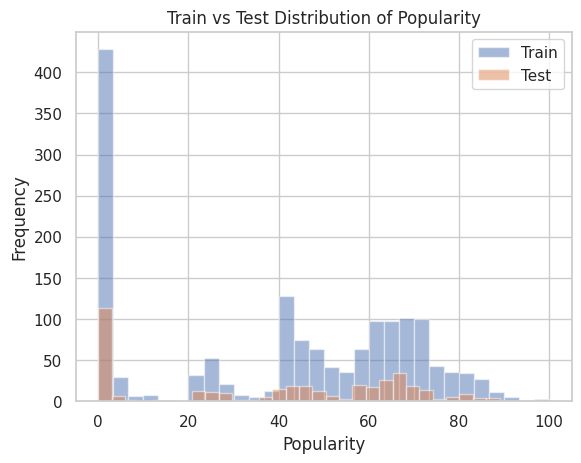

In [67]:
plt.hist(y_train, bins=30, alpha=0.5, label='Train')
plt.hist(y_test, bins=30, alpha=0.5, label='Test')

plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.title("Train vs Test Distribution of Popularity")
plt.legend()
plt.show()

This histogram visualises the shape of our data. There are peaks and low points in the same areas, but our test data is smaller, explaining the lower frequency values.
An important thing to note about our data is the big spike towards at 0 popularity, meaning our data is skewed.

This makes it a bit difficult to accurately predict popularity, but is representative of real life.

It's important to note this skew may make the model biased to being able to predict lower values more accurately.

## D. Modelling Approaches

This section contains multiple approaches to regression modelling, which I will evaluate and justify in the 'Evaluation' section.

Linear Regression is a linear approach, while Random Forest and Gradient Boosting are ensemble approaches.

### D.1 Linear Regression

In [68]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

The linear regression approach excels in linear data, which, as we can see from splitting the data, this data is not linear. So, I was curious to see how this model would perform.

I used a scaling pipeline during the modelling process to prevent datga leakage by performing the scaling only on the training data and the test data. Plus, this is the only regression model here that uses scaling.

For linear regression, having the pre-processing in the model training process leads to better results.

### D.2. Random Forest

In [69]:
rf_pipeline = Pipeline([
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ))
])

The Random Forest model is an ensemble approach, which I believe would do better than the other models which are linear. Given this, I further improved it by tuning key hyperparameters.

Controlling the max depth helps prevent overfitting, and increasing the amount of estimators helps the model's ability to learn patterns.

### D.3 Gradient Boosting Regressor

In [70]:
gb_pipeline = Pipeline([
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

The Gradient Boosting model was tuned by increasing the number of estimators and reducing the learning rate, allowing the model to learn more gradually.

Controlling the max depth helps prevent overfitting, and increasing the amount of estimators helps the model's ability to learn patterns.

## E. Evaluation

In [71]:
def evaluate(model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    return rmse, r2

This evaluation function trains the model on the training data and evaluates it on the test set using the following:
* **RMSE (Root Mean Squared Error)** represent the average prediction error of each model, with lower values meaning better accuracy.
* **R²** measures how well the model explains the variation in the target variable (popularity), with higher values indicating better performance.

Using these provides a better understanding of the evaluation of regression than, for example, accuracy.

## F. Running Models

In [72]:
results = { # defined 'results' for use in also visualising data
    "Linear Regression": evaluate(lr_pipeline),
    "Random Forest": evaluate(rf_pipeline),
    "Gradient Boosting": evaluate(gb_pipeline)
}

for model, (rmse, r2) in results.items():
    print(f"{model}: RMSE = {rmse:.2f}, R² = {r2:.3f}\n")

Linear Regression: RMSE = 28.80, R² = 0.016

Random Forest: RMSE = 25.13, R² = 0.251

Gradient Boosting: RMSE = 26.48, R² = 0.168



From running these models, we can justifiably say that random forest modelling is the best approach, due to it having the lowest RMSE and highest R².

Final model: Random Forest

## G. Visualising Data

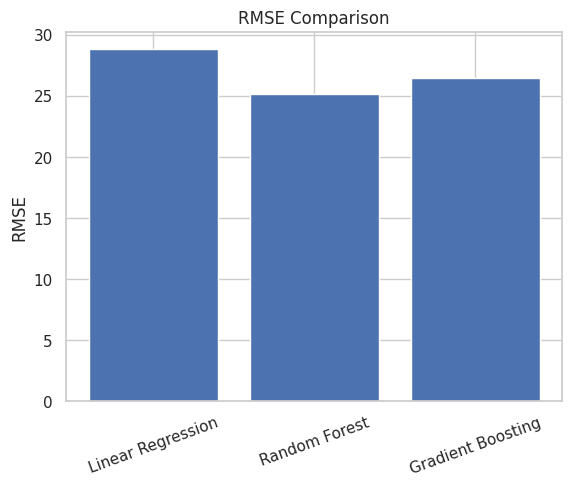

In [73]:
models = list(results.keys())
rmse_values = [results[m][0] for m in models]

plt.bar(models, rmse_values)
plt.ylabel("RMSE")
plt.title("RMSE Comparison")
plt.xticks(rotation=20)
plt.show()

The RMSE values represent the average prediction error of each model, with lower values meaning better performance.

Ensemble approaches like random forest provide better predictive accuracy for modelling popularity compared to linear models like linear regression and gradient boosting.

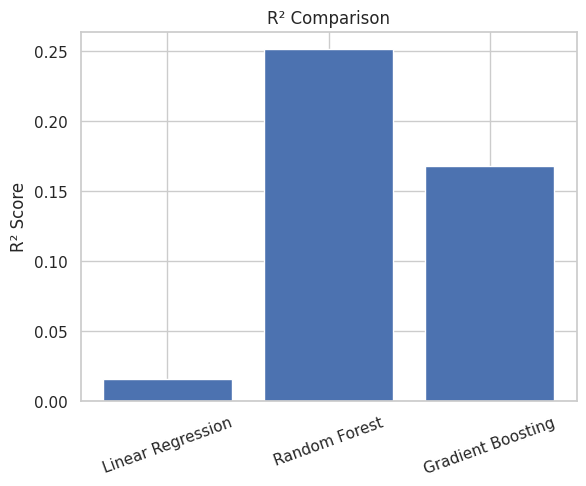

In [74]:
r2_values = [results[m][1] for m in models]

plt.bar(models, r2_values)
plt.ylabel("R² Score")
plt.title("R² Comparison")
plt.xticks(rotation=20)
plt.show()

The R² measure how well the model explains the variation in popularity, with higher values indicating better performance.

Linear regression has the lowest R² value due to the data being non-linear.

Overall, these R² values are low due to the data being affected by external factors that we cannot account for, resulting in non-linear data.

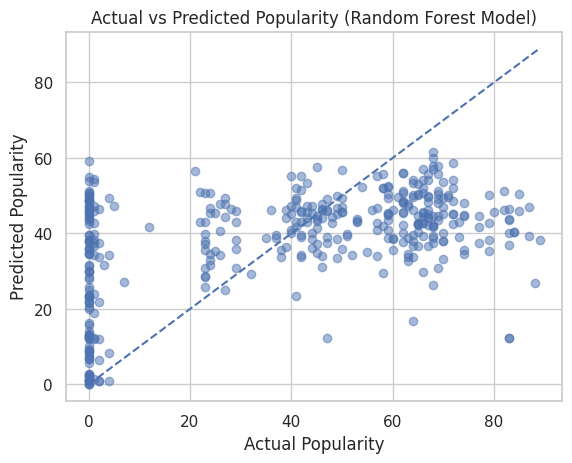

In [75]:
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted Popularity (Random Forest Model)")
plt.show()

This scatter plot visualises the relationship between actual and predicted popularity values in our best performing model, the random forest model.

## F. Exact Vs High/Low Popularity

Predicting exact popularity is more difficult than classification.
* Regression requires precise numerical predictions, making it more sensitive to errors
* Classification simplifies the task by grouping tracks into broader categories, making it easier to achieve a higher accuracy
* The low R² scores in regression show the difficulty of predicting exact popularity